# ML Model - Predict Tournament Finish

## Objectives

* This notebook aims to fulfill business requirement 3:  
   - Once they have worked with a player and gained an understanding of their 'strokes gained' performance, the client would like us to deliver a machine learning (ML) model capable of reliably predicting the finishing position of a player based on their current level of skill in each strokes gained area.

## Inputs

* Train, validation and test data:
  - outputs/data/final/train/train_data_clean.csv
  - outputs/data/final/validation/validation_data_clean.csv
  - outputs/data/final/test/test_data_clean.csv
* Scaling pipeline
  - outputs/pipelines/strokes_pipeline.pki


## Outputs

* ML Pipeline to predict tournament finish:
  - outputs/pipelines/tournament_prediction_pipeline.pki
* Feature importance plot and Prediction vs actual scattergraphs
  - outputs/pipelines/feature_importance.png
  - outputs/pipelines/pred_vs_actual_test.png
  - outputs/pipelines/pred_vs_actual_train.png
  - outputs/pipelines/pred_vs_actual_validation.png



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\project-five-golf-data-analytics\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\project-five-golf-data-analytics'

# Download Data and Scaling Pipeline

In [4]:
import pandas as pd

train_data = pd.read_csv("outputs/data/final/train/train_data_clean.csv")
val_data   = pd.read_csv("outputs/data/final/validation/val_data_clean.csv")
test_data  = pd.read_csv("outputs/data/final/test/test_data_clean.csv")
train_data.head()

,player_id,tournament_id,finish_numeric,true_pos,top_ten,mid_band,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total,adj_pos
0,9261,401353224,32.0,32.0,0,0,0.20,-0.13,-0.08,0.86,0.65,0.85,0.449275
1,5548,401353224,18.0,18.0,0,1,0.36,0.75,0.31,0.18,1.24,1.60,0.246377
2,10906,401353224,26.0,26.0,0,1,2.05,0.74,-1.32,-0.12,-0.70,1.35,0.362319
3,10372,401353224,26.0,26.0,0,1,-0.96,-0.01,1.84,0.48,2.31,1.35,0.362319
4,388,401353224,67.0,67.0,0,0,-0.82,-1.79,2.00,-1.04,-0.83,-1.65,0.956522


Split features and target for ML model

In [5]:
sg_features = ['sg_putt', 'sg_arg', 'sg_app', 'sg_ott']


X_train = train_data[sg_features]
y_train = train_data['adj_pos']

X_val = val_data[sg_features]
y_val = val_data['adj_pos']

X_test = test_data[sg_features]
y_test = test_data['adj_pos']

y_train.head()

0    0.449275
1    0.246377
2    0.362319
3    0.362319
4    0.956522
Name: adj_pos, dtype: float64

Download Scaling Pipeline.

In [6]:
import joblib
strokes_pipeline = joblib.load("outputs/pipelines/strokes_pipeline.pkl")

## Create the Model

## Random Forest Regressor

Initially, we will start with a Random Forest Regressor. Random Forests can capture nonlinear relationships quickly and effectively, unlike simple linear regression, which assumes a straight-line relationship. Since strokes gained data likely has complex, non-linear interactions, a Random Forest Regressor is a strong starting point for modeling tournament position. 

Validation Metrics:
RMSE: 0.11
MAE: 0.08
R²: 0.85


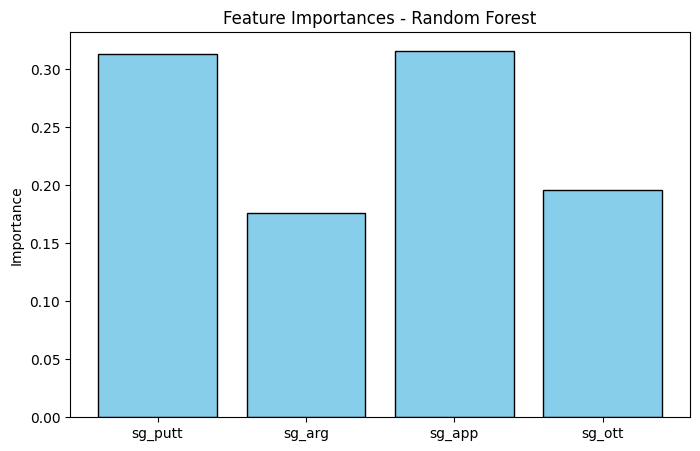

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

pipeline = Pipeline([
    ('scaler', strokes_pipeline),   # optional, RF doesn’t need scaling but you are keeping consistency
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

pipeline.fit(X_train, y_train)

y_val_pred = pipeline.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("Validation Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

model = pipeline.named_steps['model']
importances = model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(sg_features, importances, color='skyblue', edgecolor='black')
plt.title("Feature Importances - Random Forest")
plt.ylabel("Importance")
plt.show()


This feature importance graph verifies our findings that putting and approach play are the most important factors in a good tournament finishing position.

Next we will assess the ML model performance with a scatter plot.

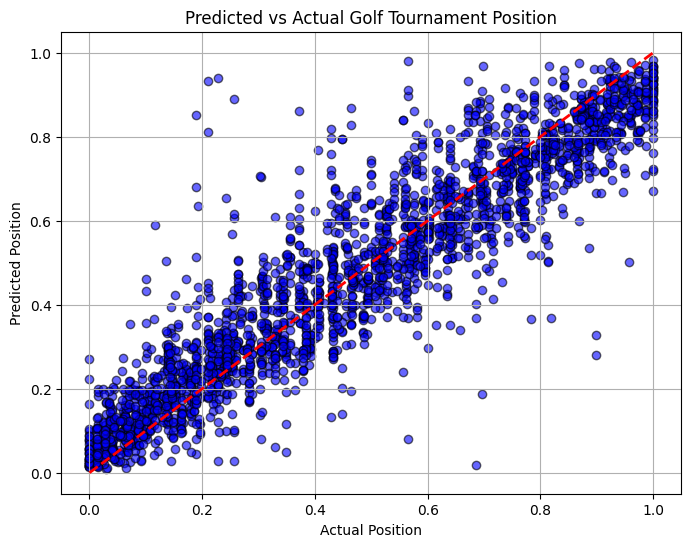

In [8]:
y_val_pred = pipeline.predict(X_val[sg_features])

plt.figure(figsize=(8,6))
plt.scatter(y_val, y_val_pred, alpha=0.6, color='blue', edgecolor='k')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', linewidth=2)
plt.xlabel("Actual Position")
plt.ylabel("Predicted Position")
plt.title("Predicted vs Actual Golf Tournament Position")
plt.grid(True)
plt.show()

Next we want to check the same model but without scaling to check for any differences.

In [9]:
X_train_f = X_train[sg_features]
y_train_f = y_train
X_val_f   = X_val[sg_features]
y_val_f   = y_val

pipeline = Pipeline([
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

pipeline.fit(X_train_f, y_train_f)

y_val_pred = pipeline.predict(X_val_f)
rmse = np.sqrt(mean_squared_error(y_val_f, y_val_pred))
mae = mean_absolute_error(y_val_f, y_val_pred)
r2 = r2_score(y_val_f, y_val_pred)

print("Validation Metrics (no scaling):")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")


Validation Metrics (no scaling):
RMSE: 0.11
MAE: 0.08
R²: 0.85


The results are identical so we will continue without scaling!

## Gradient Boosting
Gradient Boosting is a method that can capture nonlinear relationships to a high degree. It can often detect subtle interactions between features more effectively than a Random Forest, making it a good next step in creating the most accurate model.

In [10]:
from sklearn.ensemble import GradientBoostingRegressor

sg_features = ['sg_putt', 'sg_arg', 'sg_app', 'sg_ott']
X_train_f = X_train[sg_features]
y_train_f = y_train
X_val_f   = X_val[sg_features]
y_val_f   = y_val

gbr_model = GradientBoostingRegressor(
    n_estimators=200,    
    learning_rate=0.1,   
    max_depth=3,         
    random_state=42
)

gbr_model.fit(X_train_f, y_train_f)

y_val_pred = gbr_model.predict(X_val_f)

rmse = np.sqrt(mean_squared_error(y_val_f, y_val_pred))
mae = mean_absolute_error(y_val_f, y_val_pred)
r2 = r2_score(y_val_f, y_val_pred)

print("Validation Metrics (Gradient Boosting):")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")


Validation Metrics (Gradient Boosting):
RMSE: 0.11
MAE: 0.08
R²: 0.85


## XGBoost

For the final modl assessment we will try XGBoost, which can also capture nonlinear relationships and does not need feature scaling.

In [11]:
import xgboost as xgb
from sklearn.pipeline import Pipeline
import joblib

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42,
    tree_method='hist'
)

pipeline = Pipeline([
    ('model', xgb_model)
])

pipeline.fit(X_train_f, y_train_f)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0


## Conclusions
All three methods produced very similar results. Therefore we will attempt to fine-tune hyperparameters on all three models.


## Hyperparameter Optimisation
Firstly, we wil create a custom class that runs GridSearchCV for each set of hyperparameters, then summarises the results in a table for easy comparison.

In [12]:
from sklearn.model_selection import GridSearchCV

class HyperparameterOptimisationSearch:
    def __init__(self, models, params):
        """
        models: dict of sklearn pipelines or estimators, e.g., {"rf": pipeline}
        params: dict of hyperparameter grids, keys matching models
        """
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv=5, n_jobs=-1, verbose=1, scoring=None, refit=True):
        """
        Fit GridSearchCV for all models provided.
        """
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key}...\n")
            
            model = self.models[key]
            param_grid = self.params[key]
            
            gs = GridSearchCV(
                estimator=model,
                param_grid=param_grid,
                cv=cv,
                n_jobs=n_jobs,
                verbose=verbose,
                scoring=scoring,
                refit=refit
            )
            
            gs.fit(X, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):
        """
        Returns a DataFrame summarising cross-validation results for all models.
        """
        def row(key, scores, params):
            d = {
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores)
            }
            return pd.Series({**params, **d})

        rows = []
        for k in self.grid_searches:
            params_list = self.grid_searches[k].cv_results_['params']
            splits = [f'split{i}_test_score' for i in range(self.grid_searches[k].cv)]
            for i, p in enumerate(params_list):
                scores = [self.grid_searches[k].cv_results_[split][i] for split in splits]
                rows.append(row(k, scores, p))

        df = pd.DataFrame(rows).sort_values([sort_by], ascending=False)
        return df, self.grid_searches


In [13]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb


X_train_f = train_data[sg_features]
y_train_f = train_data['adj_pos']

models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(random_state=42)
}
params = {
    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, None],
        "min_samples_split": [2, 5],
    },
    "GradientBoosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5]
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }
}

search = HyperparameterOptimisationSearch(models=models, params=params)

search.fit(X_train_f, y_train_f, scoring='r2', cv=5, n_jobs=-1)

grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
print(grid_search_summary)



Running GridSearchCV for RandomForest...

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Running GridSearchCV for GradientBoosting...

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Running GridSearchCV for XGBoost...

Fitting 5 folds for each of 32 candidates, totalling 160 fits
    max_depth  min_samples_split  n_estimators         estimator  min_score  \
42        5.0                NaN           200           XGBoost   0.749832   
43        5.0                NaN           200           XGBoost   0.748070   
48        5.0                NaN           100           XGBoost   0.747171   
15        5.0                NaN           200  GradientBoosting   0.749035   
50        5.0                NaN           200           XGBoost   0.747095   
26        5.0                NaN           200           XGBoost   0.744443   
49        5.0                NaN           100           XGBoost   0.746707   
51        5.0                NaN           200           

Look at the results more clearly:

In [14]:
summary_df, grid_searches = search.score_summary(sort_by='mean_score')

import pandas as pd

columns_to_show = [
    'estimator', 'max_depth', 'min_samples_split', 'n_estimators',
    'learning_rate', 'subsample', 'colsample_bytree',
    'min_score', 'mean_score', 'max_score', 'std_score'
]

columns_to_show = [c for c in columns_to_show if c in summary_df.columns]

summary_df[columns_to_show].sort_values('mean_score', ascending=False).reset_index(drop=True)


,estimator,max_depth,min_samples_split,n_estimators,learning_rate,subsample,colsample_bytree,min_score,mean_score,max_score,std_score
0,XGBoost,5.0,NaN,200,0.05,0.8,1.0,0.749832,0.842397,0.897107,0.061418
1,XGBoost,5.0,NaN,200,0.05,1.0,1.0,0.748070,0.839197,0.893170,0.060875
2,XGBoost,5.0,NaN,100,0.10,0.8,1.0,0.747171,0.839023,0.895386,0.061779
3,GradientBoosting,5.0,NaN,200,0.05,NaN,NaN,0.749035,0.838343,0.890678,0.059368
4,XGBoost,5.0,NaN,200,0.10,0.8,1.0,0.747095,0.838148,0.897088,0.062103
5,XGBoost,5.0,NaN,200,0.05,0.8,0.8,0.744443,0.838083,0.891471,0.061292
6,XGBoost,5.0,NaN,100,0.10,1.0,1.0,0.746707,0.837867,0.891728,0.060708
7,XGBoost,5.0,NaN,200,0.10,1.0,1.0,0.746899,0.836998,0.892646,0.060781
8,XGBoost,5.0,NaN,100,0.05,0.8,1.0,0.750285,0.836918,0.887703,0.056353
9,XGBoost,5.0,NaN,200,0.10,0.8,0.8,0.745203,0.836684,0.891636,0.061369


Althgouh the best results are found using XGBoost, we are not using XGBoost due to compatibility issues on Heroku (such as GPU-related errors).  

Instead, we are using GradientBoostingRegressor with the following parameters:

- `max_depth = 5`
- `n_estimators = 200`
- `learning_rate = 0.05`

This configuration achieved the highest mean cross-validation score 
among all tested GradientBoosting hyperparameter combinations, making it 
the most reliable CPU-friendly option for deployment on Heroku.



## Use our Model on the Test Data

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gs_gb = search.grid_searches['GradientBoosting']
best_pipeline = gs_gb.best_estimator_

y_pred = best_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")


Mean Absolute Error (MAE): 0.0781
Mean Squared Error (MSE): 0.0116
Root Mean Squared Error (RMSE): 0.1078
R^2 Score: 0.8646


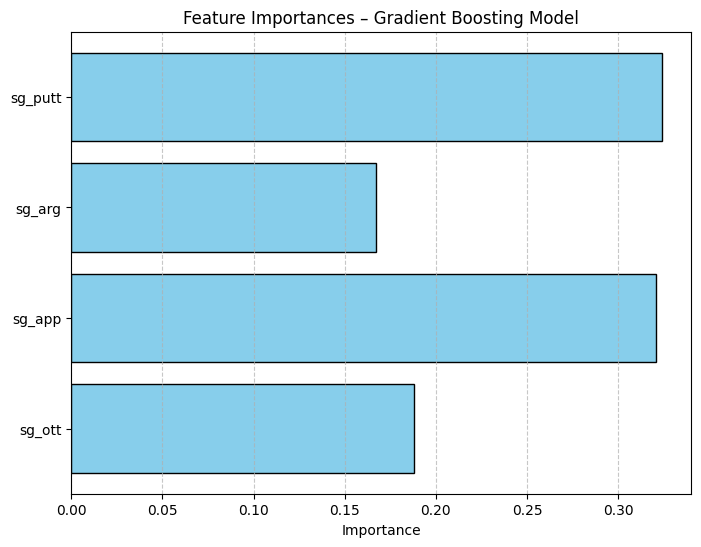

--- Train Metrics ---
MAE: 4.65
MSE: 45.44
RMSE: 6.74
R²: 0.8925


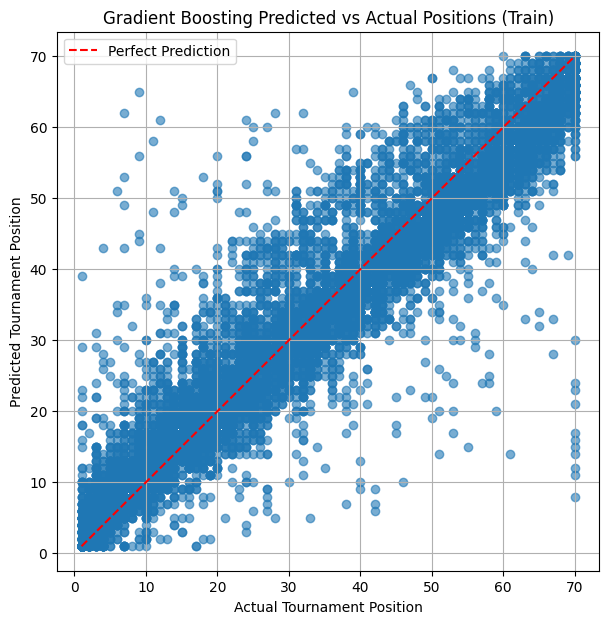

--- Validation Metrics ---
MAE: 5.54
MSE: 58.84
RMSE: 7.67
R²: 0.8616


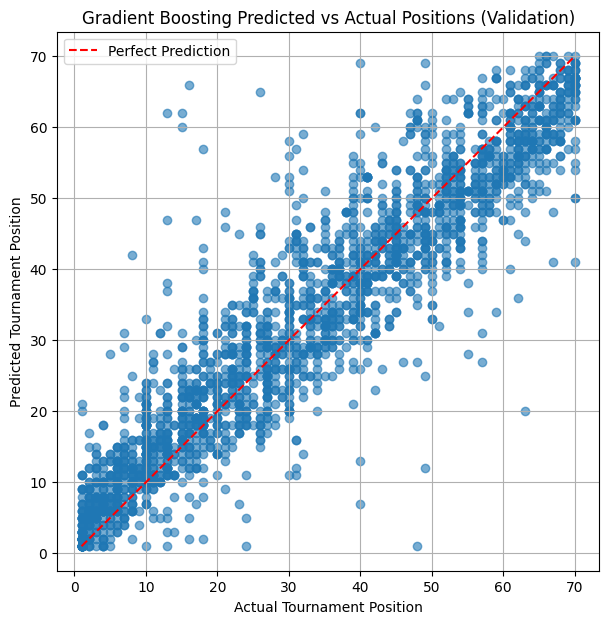

--- Test Metrics ---
MAE: 5.44
MSE: 56.90
RMSE: 7.54
R²: 0.8645


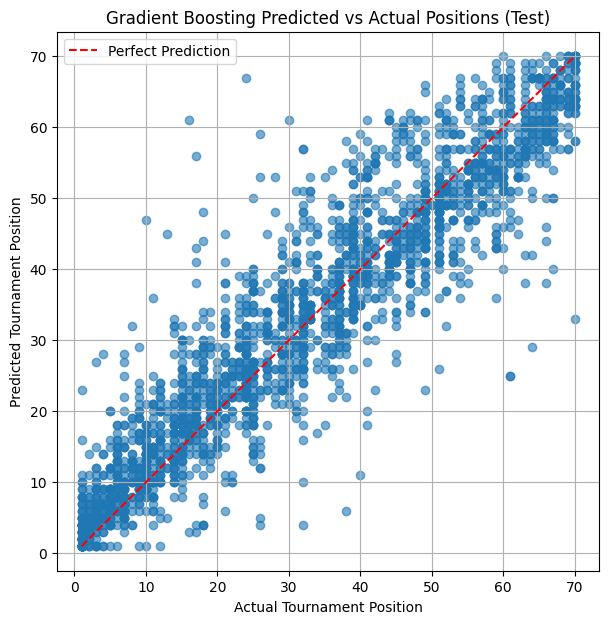

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

tournament_size = 70 

gs_gb = search.grid_searches['GradientBoosting']
best_pipeline = gs_gb.best_estimator_

sg_features = ['sg_putt', 'sg_arg', 'sg_app', 'sg_ott']

importances = best_pipeline.feature_importances_

plt.figure(figsize=(8, 6))
plt.barh(sg_features, importances, color='skyblue', edgecolor='black')
plt.xlabel("Importance")
plt.title("Feature Importances – Gradient Boosting Model")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

def evaluate_and_plot(X, y_true, dataset_name):
    y_pred = best_pipeline.predict(X)

    y_pred_unscaled = y_pred * tournament_size
    y_true_unscaled = y_true * tournament_size

    y_pred_ranks = np.clip(np.round(y_pred_unscaled).astype(int), 1, tournament_size)
    y_true_ranks = np.clip(np.round(y_true_unscaled).astype(int), 1, tournament_size)

    mae = mean_absolute_error(y_true_ranks, y_pred_ranks)
    mse = mean_squared_error(y_true_ranks, y_pred_ranks)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_ranks, y_pred_ranks)

    print(f"--- {dataset_name} Metrics ---")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    plt.figure(figsize=(7, 7))
    plt.scatter(y_true_ranks, y_pred_ranks, alpha=0.6)
    plt.plot([1, tournament_size], [1, tournament_size], 'r--', label='Perfect Prediction')
    plt.xlabel('Actual Tournament Position')
    plt.ylabel('Predicted Tournament Position')
    plt.title(f'Gradient Boosting Predicted vs Actual Positions ({dataset_name})')
    plt.legend()
    plt.grid(True)
    plt.show()


evaluate_and_plot(X_train_f, y_train_f, "Train")
evaluate_and_plot(X_val_f, y_val_f, "Validation")
evaluate_and_plot(X_test, y_test, "Test")


As the test data has an MAE within 8 positions, we can consider this a success.

## Save The Pipeline to Repo

In [17]:
import os
import joblib
import matplotlib.pyplot as plt
import numpy as np

out_dir = "outputs/pipelines"
os.makedirs(out_dir, exist_ok=True)

gb_model = best_pipeline

joblib.dump(gb_model, os.path.join(out_dir, "tournament_prediction_pipeline.pkl"))

sg_features = ['sg_putt', 'sg_arg', 'sg_app', 'sg_ott']
importances = gb_model.feature_importances_

plt.figure(figsize=(8,6))
plt.barh(sg_features, importances, color='skyblue', edgecolor='black')
plt.xlabel("Importance")
plt.title("Feature Importances – Gradient Boosting Model")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(out_dir, "feature_importance.png"))
plt.close()

def save_pred_vs_actual(X, y_true, filename, tournament_size=70):
    y_pred = gb_model.predict(X)
    y_pred_ranks = np.clip(np.round(y_pred * (tournament_size-1) + 1).astype(int),
                           1, tournament_size)
    y_true_ranks = np.clip(np.round(y_true * (tournament_size-1) + 1).astype(int),
                           1, tournament_size)
    plt.figure(figsize=(7,7))
    plt.scatter(y_true_ranks, y_pred_ranks, alpha=0.6)
    plt.plot([1, tournament_size], [1, tournament_size], 'r--', linewidth=2)
    plt.xlabel("Actual Tournament Position")
    plt.ylabel("Predicted Tournament Position")
    plt.title("Predicted vs Actual Positions – Gradient Boosting")
    plt.grid(True)
    plt.savefig(os.path.join(out_dir, filename))
    plt.close()

save_pred_vs_actual(X_train_f, y_train_f, "pred_vs_actual_train.png")
save_pred_vs_actual(X_val_f, y_val_f, "pred_vs_actual_validation.png")
save_pred_vs_actual(X_test, y_test, "pred_vs_actual_test.png")

print("Pipeline and all plots saved successfully.")


Pipeline and all plots saved successfully.
